In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

In [4]:
df

,datetime,speed,power_cf,power
0,2018-01-01 01:00:00,6.384246,0.191033,134.039
1,2018-01-01 02:00:00,6.679563,0.220842,123.450
2,2018-01-01 03:00:00,6.784414,0.232067,116.143
3,2018-01-01 04:00:00,6.794198,0.233133,94.625
4,2018-01-01 05:00:00,7.114358,0.269688,41.765
...,...,...,...,...
34851,2021-12-31 13:00:00,2.544705,0.000000,5.338
34852,2021-12-31 14:00:00,2.059370,0.000000,6.463
34853,2021-12-31 15:00:00,3.659931,0.024277,10.312
34854,2021-12-31 16:00:00,4.747566,0.070125,16.813


In [ ]:
# df1 = df[:8760]
# df2 = df[8760:17520]
# df3 = df[17520:26304]
# df4 = df[26304:]

In [5]:
# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

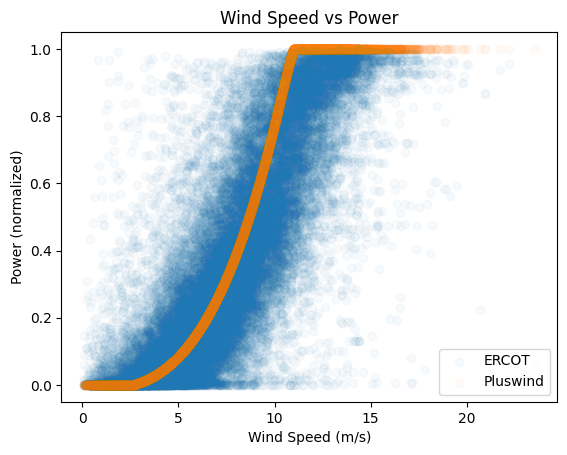

In [8]:
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (normalized)')
plt.title('Wind Speed vs Power')
plt.legend()

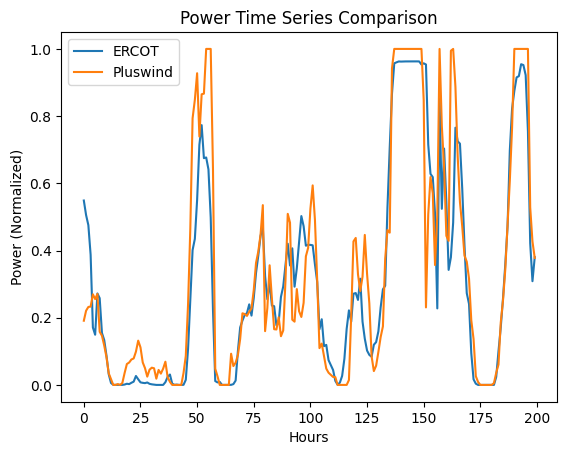

In [9]:
plt.plot(df['npower'][:200], label='ERCOT')
plt.plot(df['power_cf'][:200], label='Pluswind')
plt.title('Power Time Series Comparison')
plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.legend()

In [10]:
# split into years
df1 = df[:8596].reset_index(drop=True)         # n=8596 
df2 = df[8596:17327].reset_index(drop=True)    # n=8731
df3 = df[17327:26108].reset_index(drop=True)   # n=8781 (leap year)
df4 = df[26108:].reset_index(drop=True)        # n=8753

## seasonal fluctuations?

In [11]:
time = df1['datetime']
t = np.arange(8596)
A = 0.5
B = 0.3

seasonal = A * np.sin(2 * np.pi * t / 8596)
daily = B * np.sin(2 * np.pi * t / 24)
noise = np.random.normal(0, 0.05, size=8596)
weight = seasonal + daily + noise

sorted_power = np.sort(df1['npower'])
weight_order = np.argsort(weight)
sorted = np.empty_like(sorted_power)
sorted[weight_order] = sorted_power

df1['sorted'] = sorted

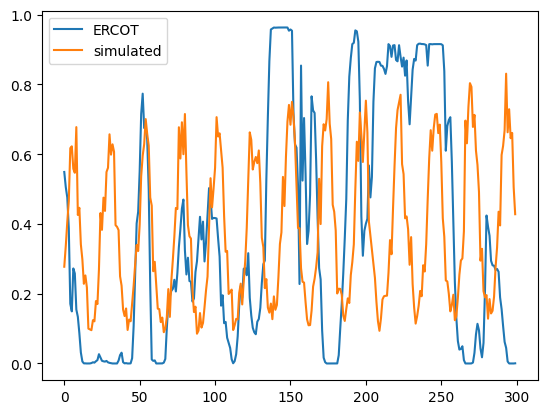

In [12]:
plt.plot(df1['npower'][:300], label='ERCOT')
plt.plot(df1['sorted'][:300], label='simulated')
plt.legend()

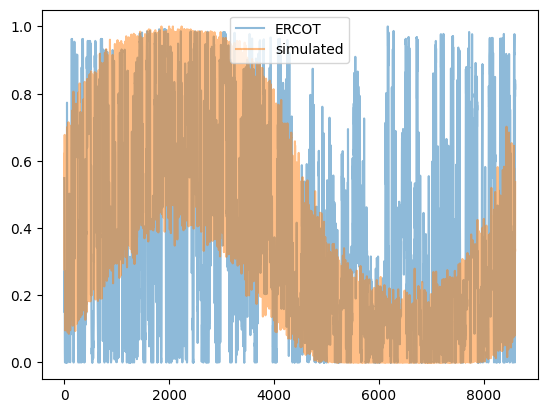

In [13]:
plt.plot(df1['npower'][:8596], label='ERCOT', alpha=0.5)
plt.plot(df1['sorted'][:8596], label='simulated', alpha=0.5)
plt.legend()

# Using deterministic power curve

$Power = 1/2 * \rho * A * v^3$

$\rho$ : density of air (kg/m^3) - standard is 1.225 kg/m^3

$A$ : cross sectional area of wind, swept area (m^2)

$v$ : velocity of wind (m/s)

pyron has 166 turbines, each operating at 1.5 MW (max)

pyron wind turbine: cut-in at 3.5 m/s, rated wind speed at 12 m/s, cut-out at 25 m/s

In [14]:
radius = 77 / 2
area = np.pi * radius**2
area

4656.625710783471

In [ ]:
# all pyron turbine power in MW
power = 0.5 * 1.225 * area * df1['speed']**3 * 166 / 1e6

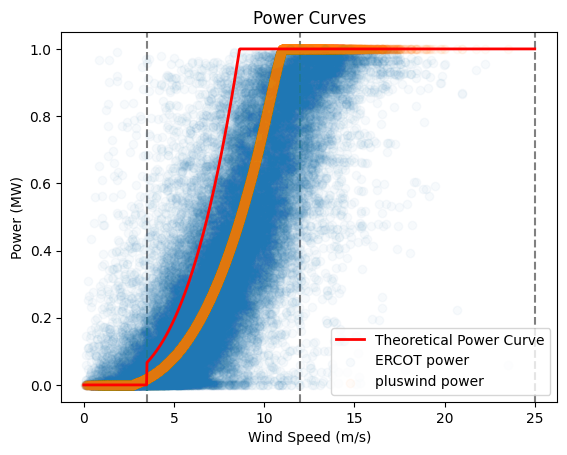

In [16]:
x = np.linspace(0, 25, 1000)

# one turbine
# y = 0.5 * area * x**3 / 1e6
# y = [1.5 if val > 1.5 else val for val in y]

# all pyron turbines
y = 0.5 * area * x**3 * 166 / 1e6
y = [0 if speed < 3.5 else val for speed, val in zip(x, y)]
y = [249 if val > 249 else val for val in y]
y = [val / 249 for val in y] # normalize
plt.plot(x, y, label='Theoretical Power Curve', color='red', linewidth=2)

plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT power')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='pluswind power')

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.title('Power Curves')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.legend()

### 5 Parameter Logistic

$ y = f(x;p) = f(x;a,b,c,d,g) = d + \frac{a-d}{(1+(\frac{x}{c})^b)^g} $

In [17]:
from scipy.optimize import curve_fit

In [18]:
def raw_5pl(x, a, b, c, d, g):
    return d + (a - d) / (1 + (x / c) ** b) ** g

# scale y to 0-249
def constrained_5pl(x, a, b, c, d, g):
    y_raw = raw_5pl(x, a, b, c, d, g)
    y_min = raw_5pl(3.5, a, b, c, d, g)
    y_max = raw_5pl(12, a, b, c, d, g)
    return 249 * (y_raw - y_min) / (y_max - y_min)

def full_power_curve(x, a, b, c, d, g):
    x = np.array(x)
    y = np.zeros_like(x)
    clipped_speeds = (x >= 3.5) & (x <= 12)
    y[clipped_speeds] = constrained_5pl(x[clipped_speeds], a, b, c, d, g)
    y[(x > 12) & (x <= 25)] = 249  # rated at 249
    return y

In [19]:
clipped_speeds = (df['speed'] >= 3.5) & (df['speed'] <= 12)
x_clip = df['speed'][clipped_speeds].values
y_clip = df['power'][clipped_speeds].values

initial_guess = [0, 1, 1, 249, 1]

params, _ = curve_fit(constrained_5pl, x_clip, y_clip, p0=initial_guess, maxfev=10000)

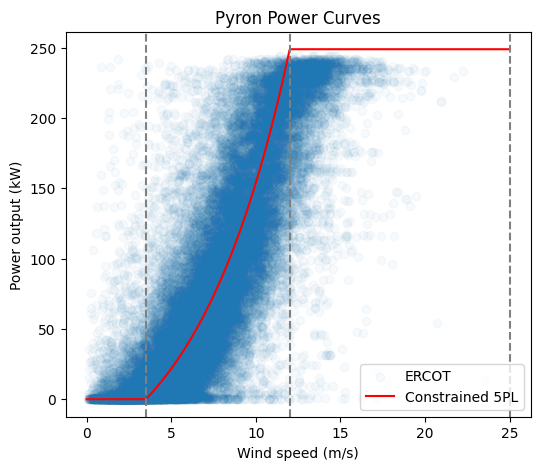

In [24]:
x = np.linspace(0, 25, 1000)
y = full_power_curve(x, *params)

plt.figure(figsize=(6, 5))
plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.plot(x, y, color='red', label='Constrained 5PL')
plt.axvline(3.5, linestyle='--', color='gray')
plt.axvline(12, linestyle='--', color='gray')
plt.axvline(25, linestyle='--', color='gray')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power output (kW)')
plt.title('Pyron Power Curves')
plt.legend()
plt.show()


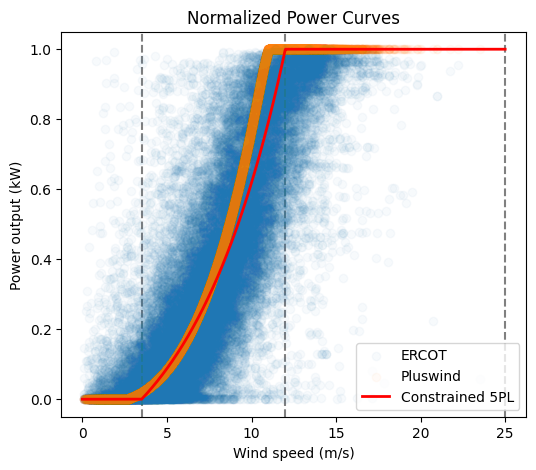

In [25]:
# normalized, plotted with pluswind

x = np.linspace(0, 25, 1000)
y = full_power_curve(x, *params)
y = [val / 249 for val in y]  # normalize

plt.figure(figsize=(6, 5))
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.plot(x, y, color='red', label='Constrained 5PL', linewidth=2)

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power output (kW)')
plt.title('Normalized Power Curves')
plt.legend()
plt.show()

In [ ]:
params

array([-2.15748257e+07,  1.15500826e+00,  3.90734372e+03, -4.71764465e+09,
       -1.36789219e+03])

In [34]:
for i in range(26):
    print(f"speed: {i}", f"power: {full_power_curve(i, *params)}")

speed: 0 power: 0
speed: 1 power: 0
speed: 2 power: 0
speed: 3 power: 0
speed: 4 power: 6
speed: 5 power: 21
speed: 6 power: 39
speed: 7 power: 61
speed: 8 power: 87
speed: 9 power: 117
speed: 10 power: 154
speed: 11 power: 197
speed: 12 power: 249
speed: 13 power: 249
speed: 14 power: 249
speed: 15 power: 249
speed: 16 power: 249
speed: 17 power: 249
speed: 18 power: 249
speed: 19 power: 249
speed: 20 power: 249
speed: 21 power: 249
speed: 22 power: 249
speed: 23 power: 249
speed: 24 power: 249
speed: 25 power: 249


## time series with deterministic curve

In [39]:
power = full_power_curve(df['speed'], *params)

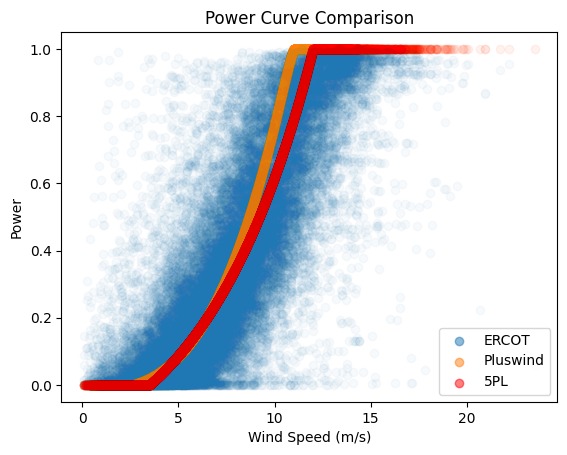

In [49]:
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.scatter(df['speed'], power/249, alpha=0.03, color='red', label='5PL')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power')
plt.title('Power Curve Comparison')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)

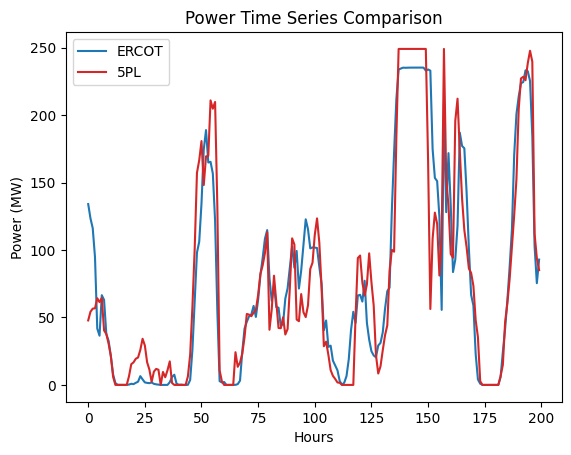

In [ ]:
# time series
plt.plot(df['power'][:200], label='ERCOT', color='tab:blue')
plt.plot(power[:200], label='5PL', color='tab:red')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Power Time Series Comparison')
plt.legend()

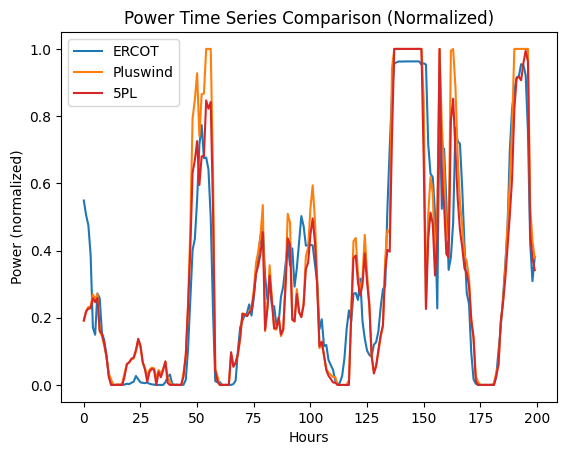

In [60]:
# normalized time series with pluswind
plt.plot(df['npower'][:200], label='ERCOT')
plt.plot(df['power_cf'][:200], label='Pluswind')
plt.plot(power[:200]/249, label='5PL', color='tab:red')
plt.xlabel('Hours')
plt.ylabel('Power (normalized)')
plt.title('Power Time Series Comparison (Normalized)')
plt.legend()

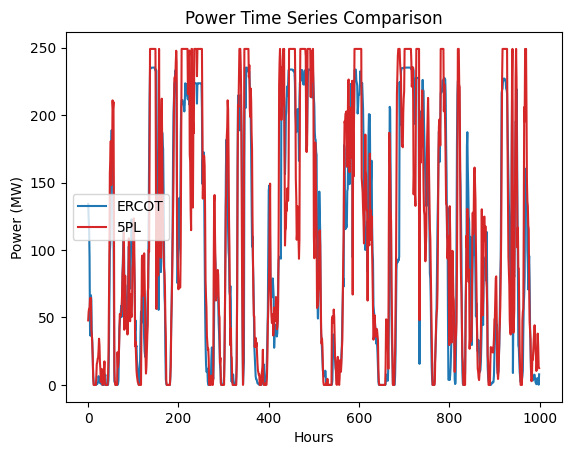

In [61]:
# time series
plt.plot(df['power'][:1000], label='ERCOT', color='tab:blue')
plt.plot(power[:1000], label='5PL', color='tab:red')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Power Time Series Comparison')
plt.legend()

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [75]:
# comparing ERCOT and Pluswind
print("MSE:", mean_squared_error(df['npower'], df['power_cf']))
print("RMSE:", root_mean_squared_error(df['npower'], df['power_cf']))
print("R2:", r2_score(df['npower'], df['power_cf']))

MSE: 0.047011942247820654
RMSE: 0.2168223748781953
R2: 0.5043963287405123


In [74]:
# comparing ERCOT and 5PL
print("MSE:", mean_squared_error(df['npower'], power/249))
print("RMSE:", root_mean_squared_error(df['npower'], power/249))
print("R2:", r2_score(df['npower'], power/249))

MSE: 0.037122683541293965
RMSE: 0.1926724773840155
R2: 0.6086496883475956
